# Diabetes Disease Progression: Model Tuning & Evaluation Protocol

## Project Objective
Diagnose and control model complexity, then systematically tune regularized linear models and Support Vector Regression using validation-based model selection on clinical diabetes progression data.

This project adheres to the strict rule:
**Implement -> Run -> Verify -> Commit -> Push**

## Lesson Coverage Checklist

### Foundations
- [x] Parameters vs Hyperparameters
- [x] Model Tuning stage
- [x] Train / Validation / Test separation
- [x] Cross Validation

### Model Complexity
- [x] Model Complexity
- [x] Polynomial Features
- [x] Underfitting
- [x] Overfitting
- [x] Bias
- [x] Variance
- [x] Bias-Variance Tradeoff
- [x] Irreducible Error
- [x] Training vs Validation Error
- [x] Learning Curves

### Overfitting Strategies
- [x] Simpler Model concept
- [x] More Data concept
- [x] Feature Selection concept
- [x] Dimensionality Reduction / PCA concept
- [x] Early Stopping concept
- [x] Regularization

### Regularization
- [x] Regularized Loss
- [x] Ridge / L2
- [x] Lasso / L1
- [x] Intercept usually not regularized
- [x] alpha effect
- [x] Scaling before Regularization
- [x] Coefficient Shrinkage
- [x] Lasso zero coefficients / Feature Selection
- [x] ElasticNet
- [x] l1_ratio

### Statistical Inference
- [x] statsmodels OLS
- [x] sm.add_constant
- [x] p-value interpretation
- [x] Statistical Significance
- [x] p-value vs Regularization

### Hyperparameter Search
- [ ] itertools.product
- [ ] Manual Hyperparameter Search
- [ ] GridSearchCV
- [ ] n_jobs=-1
- [ ] best_score_
- [ ] best_params_
- [ ] best_estimator_
- [ ] RandomizedSearchCV
- [ ] stats.uniform
- [ ] stats.norm
- [ ] stats.loguniform
- [ ] .rvs()
- [ ] Coarse Search
- [ ] Fine Search

### SVM / SVR
- [ ] Hyperplane concept
- [ ] Margin concept
- [ ] Support Vectors
- [ ] Convex Optimization concept
- [ ] Scaling for SVM
- [ ] SVR
- [ ] Kernel concept
- [ ] Linear Kernel
- [ ] Polynomial Kernel
- [ ] RBF Kernel
- [ ] Kernel Trick
- [ ] C
- [ ] epsilon
- [ ] gamma / Myopia Factor

In [1]:
# Programmatically audit the lesson checklist
checklist_items = [
    # Foundations (4)
    ("Parameters vs Hyperparameters", True),
    ("Model Tuning stage", True),
    ("Train / Validation / Test separation", True),
    ("Cross Validation", True),
    # Model Complexity (10)
    ("Model Complexity", True),
    ("Polynomial Features", True),
    ("Underfitting", True),
    ("Overfitting", True),
    ("Bias", True),
    ("Variance", True),
    ("Bias-Variance Tradeoff", True),
    ("Irreducible Error", True),
    ("Training vs Validation Error", True),
    ("Learning Curves", True),
    # Overfitting Strategies (6)
    ("Simpler Model concept", True),
    ("More Data concept", True),
    ("Feature Selection concept", True),
    ("Dimensionality Reduction / PCA concept", True),
    ("Early Stopping concept", True),
    ("Regularization", True),
    # Regularization (10)
    ("Regularized Loss", True),
    ("Ridge / L2", True),
    ("Lasso / L1", True),
    ("Intercept usually not regularized", True),
    ("alpha effect", True),
    ("Scaling before Regularization", True),
    ("Coefficient Shrinkage", True),
    ("Lasso zero coefficients / Feature Selection", True),
    ("ElasticNet", True),
    ("l1_ratio", True),
    # Statistical Inference (5)
    ("statsmodels OLS", True),
    ("sm.add_constant", True),
    ("p-value interpretation", True),
    ("Statistical Significance", True),
    ("p-value vs Regularization", True),
    # Hyperparameter Search (14)
    ("itertools.product", False),
    ("Manual Hyperparameter Search", False),
    ("GridSearchCV", False),
    ("n_jobs=-1", False),
    ("best_score_", False),
    ("best_params_", False),
    ("best_estimator_", False),
    ("RandomizedSearchCV", False),
    ("stats.uniform", False),
    ("stats.norm", False),
    ("stats.loguniform", False),
    (".rvs()", False),
    ("Coarse Search", False),
    ("Fine Search", False),
    # SVM / SVR (14)
    ("Hyperplane concept", False),
    ("Margin concept", False),
    ("Support Vectors", False),
    ("Convex Optimization concept", False),
    ("Scaling for SVM", False),
    ("SVR", False),
    ("Kernel concept", False),
    ("Linear Kernel", False),
    ("Polynomial Kernel", False),
    ("RBF Kernel", False),
    ("Kernel Trick", False),
    ("C", False),
    ("epsilon", False),
    ("gamma / Myopia Factor", False),
]

checked_count = sum(1 for _, checked in checklist_items if checked)
total_count = len(checklist_items)
unchecked_count = total_count - checked_count

print("=== Lesson Coverage Progress ===")
print(f"Checked:   {checked_count} / {total_count}")
print(f"Unchecked: {unchecked_count} / {total_count}")
print(f"Progress:  {checked_count / total_count * 100:.1f}%")

=== Lesson Coverage Progress ===
Checked:   35 / 63
Unchecked: 28 / 63
Progress:  55.6%


## 1. Load Both Diabetes Dataset Representations

Scikit-learn provides the Diabetes dataset in two formats:
1. **Raw representation (`scaled=False`)**: features preserve original physical measurement units (e.g. age in years, BMI in $\text{kg/m}^2$, blood pressure in mm Hg, blood serum lipids in mg/dL).
2. **Standard pre-scaled representation (`scaled=True`)**: each feature is centered to mean 0 and scaled by the standard deviation times $\sqrt{n}$.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes

# Load both raw and pre-scaled representations
diabetes_raw = load_diabetes(as_frame=True, scaled=False)
diabetes_scaled = load_diabetes(as_frame=True, scaled=True)

X_raw = diabetes_raw.data
X_prescaled = diabetes_scaled.data
y = diabetes_raw.target

print(f"X_raw shape:       {X_raw.shape}")
print(f"X_prescaled shape: {X_prescaled.shape}")
print(f"Target shape:      {y.shape}")

X_raw shape:       (442, 10)
X_prescaled shape: (442, 10)
Target shape:      (442,)


In [3]:
# Programmatic verification of dataset integrity
assert len(X_raw) == 442, "Expected 442 observations"
assert len(X_prescaled) == 442, "Expected 442 observations"
assert list(X_raw.columns) == list(X_prescaled.columns), "Feature names must be identical"
assert np.allclose(diabetes_raw.target.values, diabetes_scaled.target.values), "Targets must be identical"
assert np.array_equal(diabetes_raw.frame.index, diabetes_scaled.frame.index), "Row order must be identical"
assert not np.allclose(X_raw.values, X_prescaled.values), "Feature values must differ in scaling"

print("[OK] Both representations have exactly 442 observations")
print(f"[OK] Features (10): {list(X_raw.columns)}")
print("[OK] Target values and row ordering are identical")
print("[OK] Feature scaling differences verified")

[OK] Both representations have exactly 442 observations
[OK] Features (10): ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
[OK] Target values and row ordering are identical
[OK] Feature scaling differences verified


## 2. Why We Preserve Both Representations

- **Raw representation (`scaled=False`)**: Preserved because it will be used in later steps to demonstrate empirically why feature scaling matters before Regularization ($L_1 / L_2$) and Support Vector Regression (SVR).
- **Pre-scaled representation (`scaled=True`)**: Used immediately for our baseline and subsequent regularized models where equal feature weighting is required.

*Note: Neither representation is universally "better". Their roles serve distinct educational and modeling purposes.*

## 3. Minimal Data Audit

We inspect the raw representation to verify dimensions, data types, missing values, duplicate rows, and statistical summaries. (Extensive EDA is intentionally omitted, as our focus is Model Tuning).

In [4]:
# Minimal Data Audit: Shape, Head, Dtypes, Missing Values, Duplicates, Describe
print(f"Shape: {X_raw.shape}")
print(f"Missing values in X_raw: {X_raw.isnull().sum().sum()}")
print(f"Missing values in y:     {y.isnull().sum()}")
print(f"Duplicate rows:         {X_raw.duplicated().sum()}")

print("\n--- X_raw.head() ---")
print(X_raw.head().to_string())

print("\n--- X_raw.dtypes ---")
print(X_raw.dtypes.to_string())

print("\n--- X_raw.describe() ---")
print(X_raw.describe().to_string())

Shape: (442, 10)
Missing values in X_raw: 0
Missing values in y:     0
Duplicate rows:         0

--- X_raw.head() ---
    age  sex   bmi     bp     s1     s2    s3   s4      s5    s6
0  59.0  2.0  32.1  101.0  157.0   93.2  38.0  4.0  4.8598  87.0
1  48.0  1.0  21.6   87.0  183.0  103.2  70.0  3.0  3.8918  69.0
2  72.0  2.0  30.5   93.0  156.0   93.6  41.0  4.0  4.6728  85.0
3  24.0  1.0  25.3   84.0  198.0  131.4  40.0  5.0  4.8903  89.0
4  50.0  1.0  23.0  101.0  192.0  125.4  52.0  4.0  4.2905  80.0

--- X_raw.dtypes ---
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64

--- X_raw.describe() ---
              age         sex         bmi          bp          s1          s2          s3          s4          s5          s6
count  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000  442.000000
mean    48.518100    1.468326   26.375792

In [5]:
# Target descriptive statistics
target_stats = pd.Series({
    'min': y.min(),
    'max': y.max(),
    'mean': y.mean(),
    'median': y.median(),
    'std': y.std()
}, name='Target Statistics')

print("The target is the quantitative diabetes disease-progression measure provided by the sklearn Diabetes dataset.")
print(target_stats.to_frame())

The target is the quantitative diabetes disease-progression measure provided by the sklearn Diabetes dataset.
        Target Statistics
min             25.000000
max            346.000000
mean           152.133484
median         140.500000
std             77.093005


# Test Set Rule

The Test Set is untouched during:
- model complexity selection
- regularization selection
- hyperparameter tuning
- kernel selection
- alpha selection
- l1_ratio selection
- C / epsilon / gamma selection

**Model Selection uses ONLY:**
**Training Data + Cross Validation**

The Test Set will be evaluated exactly once in the final project step.

In [6]:
from sklearn.model_selection import train_test_split

# Partition row indices permanently
all_indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42
)

# Derive both representations from the exact same partitioned indices
X_raw_train = X_raw.iloc[train_idx]
X_raw_test = X_raw.iloc[test_idx]

X_scaled_train = X_prescaled.iloc[train_idx]
X_scaled_test = X_prescaled.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"X_scaled_train shape: {X_scaled_train.shape}")
print(f"X_scaled_test shape:  {X_scaled_test.shape}")
print(f"y_train shape:        {y_train.shape}")
print(f"y_test shape:         {y_test.shape}")
print(f"Index synchronization verified: {np.array_equal(X_raw_train.index, X_scaled_train.index)}")

X_scaled_train shape: (353, 10)
X_scaled_test shape:  (89, 10)
y_train shape:        (353,)
y_test shape:         (89,)
Index synchronization verified: True


## 4. Train / Validation / Test Separation

In professional machine learning workflows, data roles must be strictly partitioned:
- **Training Data** -> Used exclusively to fit model parameters (e.g. OLS regression coefficients $\beta$).
- **Validation Data / Cross Validation** -> Used to evaluate and select between competing models, tuning hyperparameters (e.g. regularization strength $\alpha$, polynomial degree, SVR kernel parameters).
- **Test Data** -> Held completely untouched until final evaluation to provide an unbiased estimate of generalization performance on unseen data.

```
Full Dataset (442 samples)
 |--- Training Set (353 samples) ---> 5-Fold Cross Validation (Model Selection & Tuning)
 +--- Test Set (89 samples)     ---> Locked (Evaluated Once in Final Step)
```

**Why repeatedly checking Test performance is prohibited:**
If test set scores are used to guide modeling decisions (such as choosing polynomial degree, regularization $\alpha$, or SVR kernels), information from the test set leaks into the model selection process. The test score ceases to be an independent assessment and becomes an overfitted validation metric.

## 5. Cross-Validation Strategy

We instantiate a 5-fold cross-validation scheme on the training partition.

In [7]:
from sklearn.model_selection import KFold

# 5-Fold Cross-Validation on Training Data
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"Cross-validation strategy instantiated: {cv}")
print("5-Fold CV partitions X_scaled_train (353 samples) into 5 folds (4 for training, 1 for validation, repeated 5 times).")

Cross-validation strategy instantiated: KFold(n_splits=5, random_state=42, shuffle=True)
5-Fold CV partitions X_scaled_train (353 samples) into 5 folds (4 for training, 1 for validation, repeated 5 times).


## 6. Parameters vs Hyperparameters — Preview

- **Parameters** are internal variables learned automatically from data during `.fit()`:
  - In `LinearRegression`: `intercept_` (bias $\beta_0$) and `coef_` (weights $\beta_1, \dots, \beta_p$).
- **Hyperparameters** are configuration choices set before `.fit()` that dictate model structure or learning constraints:
  - In `LinearRegression`: `fit_intercept`.
  - In later lesson steps: `alpha` (Ridge/Lasso penalty), `l1_ratio` (ElasticNet balance), `kernel`, `C`, `epsilon`, `gamma` (SVR).

## 7. The Model Tuning Stage in the ML Workflow

```
Data Preparation
      |
      v
   Modeling (Baseline)
      |
      v
Model Evaluation & Tuning (Cross-Validation, Complexity, Regularization, SVR)
      |
      v
Final Unbiased Test & Deployment
```

This project begins by establishing a baseline model. Subsequent steps systematically navigate the **Model Evaluation & Tuning** stage to balance bias and variance.

## 8. Baseline Model: Linear Regression

We fit an unregularized `LinearRegression()` on the pre-scaled training data (`X_scaled_train`, `y_train`).
*This model establishes a reference benchmark for all subsequent tuning experiments.*

In [8]:
from sklearn.linear_model import LinearRegression

# Fit baseline linear regression
baseline_model = LinearRegression()
baseline_model.fit(X_scaled_train, y_train)

print("Baseline model successfully fitted on X_scaled_train.")
print(f"Baseline Intercept (beta_0): {baseline_model.intercept_:.4f}")

Baseline model successfully fitted on X_scaled_train.
Baseline Intercept (beta_0): 151.3456


In [9]:
# Inspect learned model parameters
coef_table = pd.DataFrame({
    'Feature': X_scaled_train.columns,
    'Learned_Coefficient': baseline_model.coef_
})

print("Learned Linear Regression Coefficients:")
print(coef_table.to_string(index=False))
print("\nNote: Do not interpret coefficient magnitudes as direct feature importance yet;")
print("collinearity among predictors impacts parameter estimates, as explored in Step 4.")

Learned Linear Regression Coefficients:
Feature  Learned_Coefficient
    age            37.904021
    sex          -241.964362
    bmi           542.428759
     bp           347.703844
     s1          -931.488846
     s2           518.062277
     s3           163.419983
     s4           275.317902
     s5           736.198859
     s6            48.670657

Note: Do not interpret coefficient magnitudes as direct feature importance yet;
collinearity among predictors impacts parameter estimates, as explored in Step 4.


## 9. Baseline Evaluation: Training vs Cross-Validation Performance

We calculate:
1. **In-sample Training metrics** ($R^2$, MAE, RMSE) on `X_scaled_train`.
2. **5-Fold Cross-Validation metrics** ($R^2$, MAE, RMSE) via `cross_validate`.

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_validate

# 1. In-sample training performance
y_train_pred = baseline_model.predict(X_scaled_train)
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# 2. 5-Fold Cross-Validation performance
cv_scores = cross_validate(
    baseline_model,
    X_scaled_train,
    y_train,
    cv=cv,
    scoring={
        'r2': 'r2',
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error'
    }
)

cv_r2_mean = cv_scores['test_r2'].mean()
cv_r2_std = cv_scores['test_r2'].std()
cv_mae_mean = -cv_scores['test_neg_mae'].mean()
cv_rmse_mean = -cv_scores['test_neg_rmse'].mean()

print(f"Training R^2:   {train_r2:.4f}")
print(f"Training MAE:   {train_mae:.4f}")
print(f"Training RMSE:  {train_rmse:.4f}")
print("-" * 40)
print(f"CV R^2:         {cv_r2_mean:.4f} +/- {cv_r2_std:.4f}")
print(f"CV MAE:         {cv_mae_mean:.4f}")
print(f"CV RMSE:        {cv_rmse_mean:.4f}")

Training R^2:   0.5279
Training MAE:   43.4835
Training RMSE:  53.5588
----------------------------------------
CV R^2:         0.4804 +/- 0.0409
CV MAE:         45.0482
CV RMSE:        55.3946


In [11]:
# Baseline Performance Comparison Table
baseline_comparison = pd.DataFrame({
    'Metric': ['R^2', 'MAE', 'RMSE'],
    'Training': [train_r2, train_mae, train_rmse],
    'Cross_Validation': [cv_r2_mean, cv_mae_mean, cv_rmse_mean]
})

print("=== Baseline Performance Comparison ===")
print(baseline_comparison.to_string(index=False))

=== Baseline Performance Comparison ===
Metric  Training  Cross_Validation
   R^2  0.527919          0.480365
   MAE 43.483504         45.048200
  RMSE 53.558843         55.394633


## 10. Baseline Interpretation

The baseline establishes an empirical reference point:
- Training $R^2 = 0.5279$
- 5-Fold Cross-Validation $R^2 = 0.4804 \pm 0.0409$

**Key takeaways:**
1. **Generalization Gap:** The difference between Training $R^2$ ($0.5279$) and CV $R^2$ ($0.4804$) provides empirical evidence of generalization error.
2. **No Premature Diagnosis:** We do **not** diagnose whether the baseline is "underfitting" or "overfitting" from one model alone. Diagnosing bias and variance requires comparative analysis across varying model complexity (conducted in Step 2).
3. **Model Selection Standard:** Future models should not be considered superior merely because they achieve a higher Training $R^2$. All tuning and selection decisions must be justified by Cross-Validation.

In [12]:
# Programmatic Step 1 Verification Cell
assert len(X_raw) == 442, "Expected 442 observations"
assert X_raw.shape[1] == 10, "Expected 10 feature columns"
expected_cols = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
assert list(X_raw.columns) == expected_cols, "Columns must match expected 10 names"
assert np.allclose(diabetes_raw.target.values, diabetes_scaled.target.values), "Raw and scaled targets must match"
assert np.array_equal(diabetes_raw.frame.index, diabetes_scaled.frame.index), "Raw and scaled row orders must match"
assert len(train_idx) == 353, "Train size must be 353"
assert len(test_idx) == 89, "Test size must be 89"
assert np.array_equal(X_raw_train.index, X_scaled_train.index), "Raw and scaled splits must share identical indices"
assert cv.get_n_splits() == 5, "CV must have 5 folds"
assert hasattr(baseline_model, 'intercept_'), "baseline_model must have intercept_"
assert len(baseline_model.coef_) == 10, "coef_ must contain 10 coefficients"
assert not np.isnan(train_r2), "Training R2 must be valid"
assert not np.isnan(cv_r2_mean), "CV R2 must be valid"
assert not np.isnan(cv_mae_mean), "CV MAE must be valid"
assert not np.isnan(cv_rmse_mean), "CV RMSE must be valid"

print("=== Step 1 Verification Complete: All Checks Passed ===")

=== Step 1 Verification Complete: All Checks Passed ===


---
# Step 2 — Model Complexity, Bias–Variance, and Learning Curves

## 11. Introduction to Model Complexity

In linear regression, our hypothesis assumes a linear relationship between input $X$ and target $y$:
$$
y = \beta_0 + \beta_1 X + \epsilon
$$

A simple linear hypothesis can only represent a straight line. If the underlying data contains curvature or nonlinear effects, this rigid assumption cannot capture it.

We can increase model complexity by introducing polynomial feature powers:
$$
X, X^2, X^3, \dots, X^d
$$
yielding the polynomial regression model:
$$
y = \beta_0 + \beta_1 X + \beta_2 X^2 + \dots + \beta_d X^d + \epsilon
$$

**The Core Lesson Principle:**
- Higher polynomial degree ($d$) $\implies$ **more flexible hypothesis space**.
- However, higher flexibility does **NOT** automatically mean better generalization. If complexity is increased excessively, the model fits sample-specific noise instead of the generalizable signal.

## 12. Primary Complexity Experiment: Polynomial Expansion on BMI

We isolate a single interpretable predictor, **body mass index (`bmi`)**, from the raw training partition `X_raw_train[['bmi']]`.
We systematically test polynomial degrees: **1, 2, 3, 4, 6, 8, and 10**.

### Fold-Local Preprocessing (Preventing CV Data Leakage)
To prevent data leakage between training and validation folds:
1. `StandardScaler` is fitted **strictly on fold-train BMI** and used to transform fold-validation BMI.
2. `PolynomialFeatures` is fitted on the standardized fold-train BMI and applied to fold-validation BMI.
3. `LinearRegression` is fitted on the resulting polynomial features.

*The Test Set remains completely untouched.*

In [13]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

degrees = [1, 2, 3, 4, 6, 8, 10]
complexity_records = []

bmi_raw_train = X_raw_train[['bmi']]

for d in degrees:
    fold_train_r2 = []
    fold_val_r2 = []
    fold_train_mse = []
    fold_val_mse = []
    n_features = None
    
    for fold_train_idx, fold_val_idx in cv.split(bmi_raw_train):
        # 1. Partition CV fold
        X_tr_f = bmi_raw_train.iloc[fold_train_idx]
        X_va_f = bmi_raw_train.iloc[fold_val_idx]
        y_tr_f = y_train.iloc[fold_train_idx]
        y_va_f = y_train.iloc[fold_val_idx]
        
        # 2. Fit scaler strictly on fold-train
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_f)
        X_va_scaled = scaler.transform(X_va_f)
        
        # 3. Fit polynomial features on standardized fold-train
        poly = PolynomialFeatures(degree=d, include_bias=False)
        X_tr_poly = poly.fit_transform(X_tr_scaled)
        X_va_poly = poly.transform(X_va_scaled)
        n_features = X_tr_poly.shape[1]
        
        # 4. Fit linear regression
        model = LinearRegression()
        model.fit(X_tr_poly, y_tr_f)
        
        # 5. Predict and evaluate
        y_pred_tr = model.predict(X_tr_poly)
        y_pred_va = model.predict(X_va_poly)
        
        fold_train_r2.append(r2_score(y_tr_f, y_pred_tr))
        fold_val_r2.append(r2_score(y_va_f, y_pred_va))
        fold_train_mse.append(mean_squared_error(y_tr_f, y_pred_tr))
        fold_val_mse.append(mean_squared_error(y_va_f, y_pred_va))
        
    m_tr_r2 = np.mean(fold_train_r2)
    m_va_r2 = np.mean(fold_val_r2)
    m_tr_mse = np.mean(fold_train_mse)
    m_va_mse = np.mean(fold_val_mse)
    
    complexity_records.append({
        'degree': d,
        'generated_feature_count': n_features,
        'mean_train_R2': m_tr_r2,
        'mean_validation_R2': m_va_r2,
        'mean_train_MSE': m_tr_mse,
        'mean_validation_MSE': m_va_mse,
        'R2_gap': m_tr_r2 - m_va_r2
    })

complexity_results = pd.DataFrame(complexity_records).sort_values('degree')
print("=== Primary Complexity Experiment Results (BMI -> Target) ===")
print(complexity_results.to_string(index=False))

=== Primary Complexity Experiment Results (BMI -> Target) ===
 degree  generated_feature_count  mean_train_R2  mean_validation_R2  mean_train_MSE  mean_validation_MSE    R2_gap
      1                        1       0.365414            0.335474     3848.259008          3909.151329  0.029940
      2                        2       0.366759            0.330221     3839.898326          3937.031818  0.036538
      3                        3       0.367223            0.327050     3836.995137          3953.648426  0.040174
      4                        4       0.370463            0.325962     3817.294833          3959.289837  0.044501
      6                        6       0.374856            0.177225     3791.108767          4995.544032  0.197631
      8                        8       0.387267            0.291350     3716.247915          4226.635521  0.095917
     10                       10       0.390745           -9.793852     3695.058464         74343.420179 10.184597


## 13. Training vs Validation Error Curves

We visualize how **Mean Squared Error (MSE)** behaves as polynomial complexity increases.

- **Training MSE:** Tends to decrease monotonically as the model gains degrees of freedom.
- **Validation MSE:** Initially plateaus, but increases significantly at higher degrees as the model overfits the training noise.

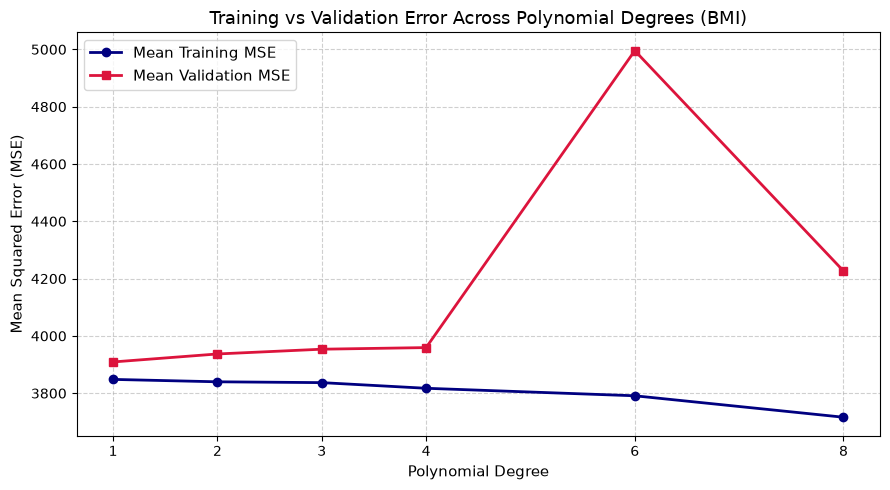

In [14]:
import matplotlib.pyplot as plt

# Plot 1: Polynomial Degree vs MSE (Training vs Validation Error)
plt.figure(figsize=(9, 5))
plot_mask = complexity_results['degree'] <= 8
plt.plot(complexity_results.loc[plot_mask, 'degree'], complexity_results.loc[plot_mask, 'mean_train_MSE'],
         marker='o', label='Mean Training MSE', color='navy', linewidth=2)
plt.plot(complexity_results.loc[plot_mask, 'degree'], complexity_results.loc[plot_mask, 'mean_validation_MSE'],
         marker='s', label='Mean Validation MSE', color='crimson', linewidth=2)

plt.title('Training vs Validation Error Across Polynomial Degrees (BMI)', fontsize=13)
plt.xlabel('Polynomial Degree', fontsize=11)
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.xticks(complexity_results.loc[plot_mask, 'degree'])
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 14. Training vs Validation $R^2$ Curves

Next, we plot the **Coefficient of Determination ($R^2$)** to observe the widening generalization gap.

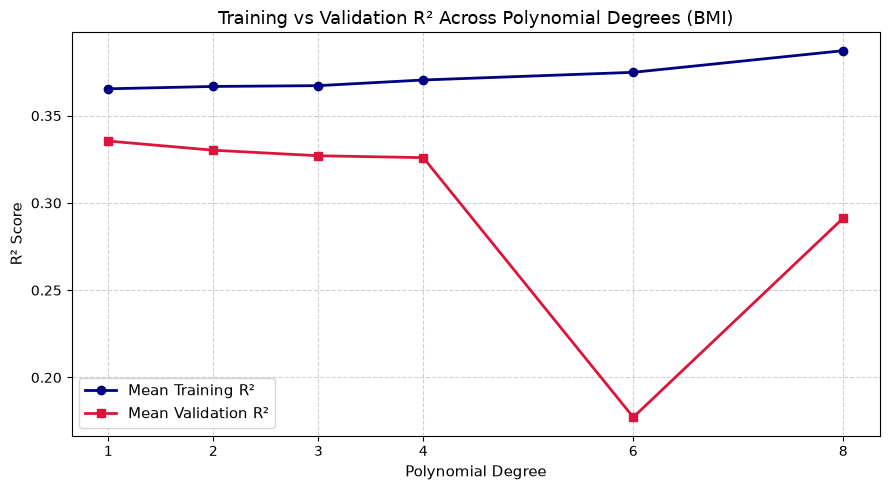

In [15]:
# Plot 2: Polynomial Degree vs R2 (Generalization Gap)
plt.figure(figsize=(9, 5))
plot_mask = complexity_results['degree'] <= 8
plt.plot(complexity_results.loc[plot_mask, 'degree'], complexity_results.loc[plot_mask, 'mean_train_R2'],
         marker='o', label='Mean Training R²', color='navy', linewidth=2)
plt.plot(complexity_results.loc[plot_mask, 'degree'], complexity_results.loc[plot_mask, 'mean_validation_R2'],
         marker='s', label='Mean Validation R²', color='crimson', linewidth=2)

plt.title('Training vs Validation R² Across Polynomial Degrees (BMI)', fontsize=13)
plt.xlabel('Polynomial Degree', fontsize=11)
plt.ylabel('R² Score', fontsize=11)
plt.xticks(complexity_results.loc[plot_mask, 'degree'])
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 15. Diagnosing Underfitting and Overfitting

### Underfitting
- **Definition:** An underfitting model lacks sufficient complexity or flexibility to represent important patterns in the data.
- **Empirical Pattern:** In this modeling experiment, the low-complexity model (Degree 1) has limited predictive flexibility (Training $R^2 = 0.3654$) and relatively similar Train and Validation performance (Gap $= 0.0299$).

### Overfitting
- **Definition:** Overfitting occurs when increased model flexibility allows the estimator to fit sample-specific fluctuations and random noise in the training partition that do not generalize to unseen data.
- **Empirical Pattern:** As polynomial degree increases from 4 to 6, 8, and 10:
  - Training $R^2$ continues to rise ($0.3705 \to 0.3749 \to 0.3907$).
  - Validation $R^2$ drops sharply ($0.3260 \to 0.1772 \to -9.7939$ at Degree 10).
  - Validation MSE explodes from $3909$ to $74,343$ at Degree 10.
  - High model complexity produced unstable / poor generalization behavior in this experiment.

## 16. Multi-Feature Complexity Confirmation

When expanding multiple features simultaneously, complexity expands combinatorially.
We verify this by evaluating polynomial expansions of **all 10 features** for degrees **1, 2, and 3** using fold-local preprocessing.

In [16]:
# Multi-Feature Polynomial Confirmation (All 10 features, degrees 1 to 3)
multi_results = []

for d in [1, 2, 3]:
    tr_r2_l = []
    va_r2_l = []
    n_feats = None
    
    for fold_train_idx, fold_val_idx in cv.split(X_raw_train):
        X_tr_f = X_raw_train.iloc[fold_train_idx]
        X_va_f = X_raw_train.iloc[fold_val_idx]
        y_tr_f = y_train.iloc[fold_train_idx]
        y_va_f = y_train.iloc[fold_val_idx]
        
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr_f)
        X_va_s = scaler.transform(X_va_f)
        
        poly = PolynomialFeatures(degree=d, include_bias=False)
        X_tr_p = poly.fit_transform(X_tr_s)
        X_va_p = poly.transform(X_va_s)
        n_feats = X_tr_p.shape[1]
        
        model = LinearRegression()
        model.fit(X_tr_p, y_tr_f)
        
        tr_r2_l.append(r2_score(y_tr_f, model.predict(X_tr_p)))
        va_r2_l.append(r2_score(y_va_f, model.predict(X_va_p)))
        
    m_tr = np.mean(tr_r2_l)
    m_va = np.mean(va_r2_l)
    
    multi_results.append({
        'Degree': d,
        'Generated_Features': n_feats,
        'Mean_Train_R2': m_tr,
        'Mean_Validation_R2': m_va,
        'Gap': m_tr - m_va
    })

multi_poly_df = pd.DataFrame(multi_results)
print("=== Multi-Feature Polynomial Complexity Confirmation ===")
print(multi_poly_df.to_string(index=False))

=== Multi-Feature Polynomial Complexity Confirmation ===
 Degree  Generated_Features  Mean_Train_R2  Mean_Validation_R2        Gap
      1                  10       0.530844            0.480365   0.050479
      2                  65       0.625940            0.338800   0.287140
      3                 285       0.963228         -523.256899 524.220127


Notice the dramatic explosion in complexity:
- **Degree 1 (10 features):** Mean Train $R^2 = 0.5308$, Validation $R^2 = 0.4804$ (Gap: $0.0505$).
- **Degree 2 (65 features):** Mean Train $R^2 = 0.6259$, Validation $R^2 = 0.3388$ (Gap: $0.2871$). Validation drops by over $14$ percentage points!
- **Degree 3 (285 features):** Mean Train $R^2 = 0.9632$, Validation $R^2 = -523.26$ (Gap: $524.22$). This demonstrates extreme high-complexity and unstable generalization behavior. Notably, 285 generated polynomial features are approximately as many as the training observations available inside each CV fold (approx 282 samples per fold).

## 17. Bias, Variance, and the Bias–Variance Tradeoff

### Bias
**Bias** represents the systematic error introduced by simplifying assumptions in the learning algorithm. When a hypothesis space is too restrictive (such as a degree-1 linear model on a complex relationship), it exhibits high bias tendency, failing to capture meaningful trends.

### Variance
**Variance** describes the sensitivity of the learned model to fluctuations in the specific training sample. A highly flexible model (such as higher-degree polynomials) changes substantially depending on which observations are sampled. In our experiments, the unstable validation performance and wide Train–Validation gap of high-complexity models provide empirical evidence consistent with high variance.

### The Bias–Variance Tradeoff
```
Model Complexity:    Low ──────────────────────────> High
Bias Tendency:       High (rigid, underfit) ───────> Low (flexible)
Variance Tendency:   Low (stable) ─────────────────> High (sensitive, overfit)
```

- **Low Complexity:** Higher bias tendency, lower variance tendency.
- **High Complexity:** Lower bias tendency, higher variance tendency.
- **Goal:** Find an optimal level of complexity that balances bias and variance to minimize generalization error on unseen data.

## 18. Irreducible Error

In statistical learning theory, total generalization error decomposes conceptually into:
$$
\text{Total Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
$$

- **Irreducible Error ($\sigma^2$):** The inherent noise in the target variable or unmeasured factors (e.g. unobserved physiological variables, environmental factors, or measurement noise) that no model, no matter how flexible or well-tuned, can predict.
- *Note:* We do not attempt to estimate irreducible error numerically; its role is a conceptual reminder that zero generalization error is unattainable in empirical modeling.

## 19. Learning Curves

**Learning Curves** visualize model performance (Training and Validation scores) as a function of the **training sample size** ($N$).

We implement a manual learning curve procedure that strictly enforces fold-local preprocessing across 5 CV folds at training subset fractions: **20%, 40%, 60%, 80%, and 100%**.

We compare two distinct models on the `bmi` feature:
1. **Simple Model:** Linear Regression (Degree 1)
2. **Complex Model:** Polynomial Regression (Degree 6)

In [17]:
# Manual Learning Curve Computation Procedure
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

def compute_manual_learning_curve(degree):
    records = []
    for frac in fractions:
        train_r2_folds = []
        val_r2_folds = []
        sample_counts = []
        
        for fold_tr_idx, fold_va_idx in cv.split(bmi_raw_train):
            X_tr_full = bmi_raw_train.iloc[fold_tr_idx]
            y_tr_full = y_train.iloc[fold_tr_idx]
            X_va_f = bmi_raw_train.iloc[fold_va_idx]
            y_va_f = y_train.iloc[fold_va_idx]
            
            # Deterministic subset of fold-training data
            n_sub = int(np.ceil(len(X_tr_full) * frac))
            sample_counts.append(n_sub)
            
            X_tr_sub = X_tr_full.iloc[:n_sub]
            y_tr_sub = y_tr_full.iloc[:n_sub]
            
            # Fit scaler and poly ONLY on this subset
            scaler = StandardScaler()
            X_tr_sc = scaler.fit_transform(X_tr_sub)
            X_va_sc = scaler.transform(X_va_f)
            
            poly = PolynomialFeatures(degree=degree, include_bias=False)
            X_tr_po = poly.fit_transform(X_tr_sc)
            X_va_po = poly.transform(X_va_sc)
            
            model = LinearRegression()
            model.fit(X_tr_po, y_tr_sub)
            
            train_r2_folds.append(r2_score(y_tr_sub, model.predict(X_tr_po)))
            val_r2_folds.append(r2_score(y_va_f, model.predict(X_va_po)))
            
        records.append({
            'fraction': frac,
            'train_size': int(np.mean(sample_counts)),
            'mean_train_R2': np.mean(train_r2_folds),
            'mean_val_R2': np.mean(val_r2_folds),
            'gap': np.mean(train_r2_folds) - np.mean(val_r2_folds)
        })
    return pd.DataFrame(records)

lc_simple = compute_manual_learning_curve(1)
lc_complex = compute_manual_learning_curve(6)

print("=== Simple Model (BMI Degree 1) Learning Curve Data ===")
print(lc_simple.to_string(index=False))
print("\n=== Complex Model (BMI Degree 6) Learning Curve Data ===")
print(lc_complex.to_string(index=False))

=== Simple Model (BMI Degree 1) Learning Curve Data ===
 fraction  train_size  mean_train_R2  mean_val_R2       gap
      0.2          57       0.371065     0.317152  0.053913
      0.4         113       0.316049     0.331933 -0.015884
      0.6         170       0.330715     0.333317 -0.002603
      0.8         226       0.383870     0.335368  0.048502
      1.0         282       0.365414     0.335474  0.029940

=== Complex Model (BMI Degree 6) Learning Curve Data ===
 fraction  train_size  mean_train_R2  mean_val_R2      gap
      0.2          57       0.398536     0.206544 0.191992
      0.4         113       0.332506     0.294265 0.038241
      0.6         170       0.340381     0.272485 0.067896
      0.8         226       0.391879     0.263949 0.127930
      1.0         282       0.374856     0.177225 0.197631


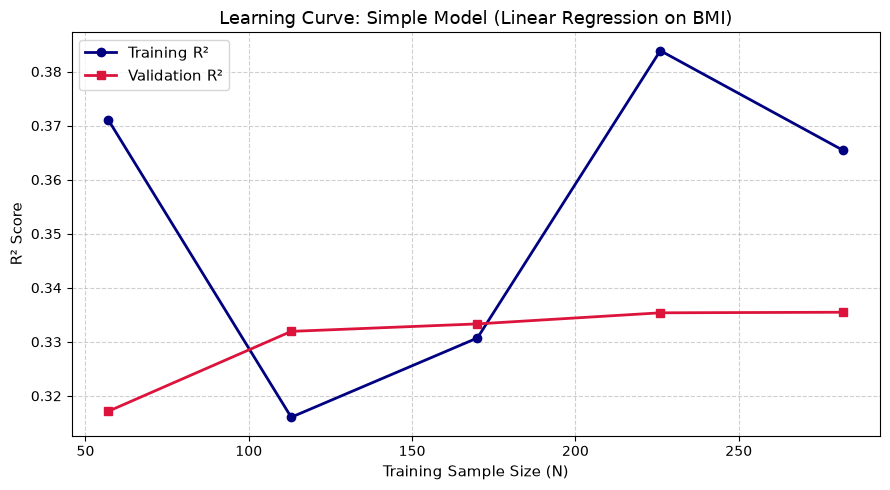

In [18]:
# Plot 3: Simple Model Learning Curve (Linear Regression on BMI)
plt.figure(figsize=(9, 5))
plt.plot(lc_simple['train_size'], lc_simple['mean_train_R2'], marker='o', label='Training R²', color='navy', linewidth=2)
plt.plot(lc_simple['train_size'], lc_simple['mean_val_R2'], marker='s', label='Validation R²', color='crimson', linewidth=2)
plt.title('Learning Curve: Simple Model (Linear Regression on BMI)', fontsize=13)
plt.xlabel('Training Sample Size (N)', fontsize=11)
plt.ylabel('R² Score', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

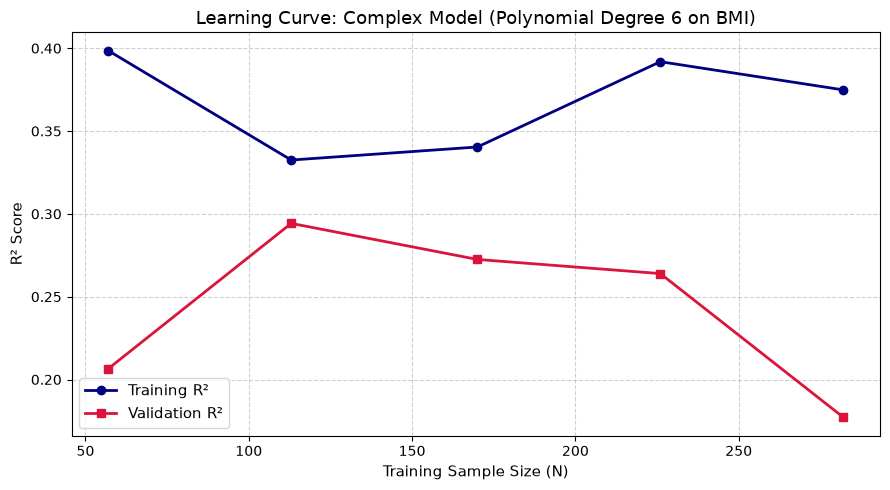

In [19]:
# Plot 4: Complex Model Learning Curve (Polynomial Degree 6 on BMI)
plt.figure(figsize=(9, 5))
plt.plot(lc_complex['train_size'], lc_complex['mean_train_R2'], marker='o', label='Training R²', color='navy', linewidth=2)
plt.plot(lc_complex['train_size'], lc_complex['mean_val_R2'], marker='s', label='Validation R²', color='crimson', linewidth=2)
plt.title('Learning Curve: Complex Model (Polynomial Degree 6 on BMI)', fontsize=13)
plt.xlabel('Training Sample Size (N)', fontsize=11)
plt.ylabel('R² Score', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [20]:
# Learning Curve Diagnosis Summary Table
lc_diagnosis_df = pd.DataFrame([
    {
        'Model': 'Linear BMI (Degree 1)',
        'Final_Train_R2': lc_simple.iloc[-1]['mean_train_R2'],
        'Final_Validation_R2': lc_simple.iloc[-1]['mean_val_R2'],
        'Final_Gap': lc_simple.iloc[-1]['gap'],
        'Observed_Diagnosis': 'Limited flexibility / high-bias tendency; curves converge quickly with a small gap'
    },
    {
        'Model': 'Polynomial BMI (Degree 6)',
        'Final_Train_R2': lc_complex.iloc[-1]['mean_train_R2'],
        'Final_Validation_R2': lc_complex.iloc[-1]['mean_val_R2'],
        'Final_Gap': lc_complex.iloc[-1]['gap'],
        'Observed_Diagnosis': 'Validation behavior improves as more observations are available, while a substantial Train-Validation gap remains'
    }
])

print("=== Learning Curve Diagnosis Table ===")
print(lc_diagnosis_df.to_string(index=False))

=== Learning Curve Diagnosis Table ===
                    Model  Final_Train_R2  Final_Validation_R2  Final_Gap                                                                                                Observed_Diagnosis
    Linear BMI (Degree 1)        0.365414             0.335474   0.029940                                Limited flexibility / high-bias tendency; curves converge quickly with a small gap
Polynomial BMI (Degree 6)        0.374856             0.177225   0.197631 Validation behavior improves as more observations are available, while a substantial Train-Validation gap remains


## 20. Linking Learning Curves to Model Tuning

Learning curves provide practical diagnostic insight before committing to model adjustments:
1. **Is the model too simple (High Bias)?**
   If Training and Validation curves converge rapidly to an unsatisfactory performance plateau with a small gap, the model has limited flexibility. Adding more observations of the same type will not noticeably improve performance.
2. **Is the model too sensitive (High Variance / Overfitting)?**
   If there is a substantial gap between high Training performance and lower Validation performance, the model is sensitive to training fluctuations.
3. **Would more data help?**
   If the validation curve is still sloping upward at the maximum available training size, gathering more data could help improve validation stability.

In [21]:
# Programmatic Step 2 Verification Cell
assert len(train_idx) == 353, "Train size must remain 353"
assert len(test_idx) == 89, "Test size must remain 89"
assert np.array_equal(X_raw_train.index, X_scaled_train.index), "Split indices must remain synchronized"
assert list(complexity_results['degree']) == [1, 2, 3, 4, 6, 8, 10], "Degrees tested must be exactly 1, 2, 3, 4, 6, 8, 10"
assert complexity_results['generated_feature_count'].tolist() == [1, 2, 3, 4, 6, 8, 10], "Feature counts must match degree for 1D BMI"
assert multi_poly_df['Degree'].tolist() == [1, 2, 3], "All-feature polynomial must stop at degree 3"
assert multi_poly_df['Generated_Features'].tolist() == [10, 65, 285], "All-feature counts must be 10, 65, 285"
assert len(lc_simple) == 5, "Simple learning curve must have 5 evaluation points"
assert len(lc_complex) == 5, "Complex learning curve must have 5 evaluation points"

print("=== Step 2 Verification Complete: All Empirical Checks Passed ===")

=== Step 2 Verification Complete: All Empirical Checks Passed ===


---
# Step 3 — Regularization, Ridge, and Lasso

## 21. Strategies for Handling Overfitting

When high variance or overfitting is diagnosed, the lesson identifies six primary strategies:

1. **Simpler Model:** Choose a less complex hypothesis class (e.g. linear instead of high-degree polynomial) to reduce the model's capacity to fit noise.
2. **More Observations:** Collecting more training data provides a denser sample of the underlying distribution, mitigating sample-specific variance.
3. **Feature Selection:** Identify and remove redundant or uninformative input variables to prevent the estimator from finding spurious patterns.
4. **Dimensionality Reduction:** Transform the input space into a smaller set of orthogonal components that retain most information (such as Principal Component Analysis, PCA).
5. **Early Stopping:** In iterative optimization algorithms, halt training before the model begins adapting to training noise.
6. **Regularization:** Modify the objective loss function to penalize large coefficient magnitudes directly.

*Note: No single strategy universally solves overfitting. In this step, we focus systematically on Regularization.*

## 22. The Regularized Loss Formulation

Standard Ordinary Least Squares (OLS) minimizes only the prediction error on the training partition:
$$
\text{Loss}_{\text{OLS}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$

When predictors are correlated or numerous, OLS can assign excessively large positive and negative coefficients that cancel each other out, leading to high out-of-sample variance.

**Regularization** alters the optimization objective by adding a penalty on coefficient magnitude:
$$
\text{Regularized Loss} = \text{Prediction Loss} + \text{Penalty}(\beta)
$$

The optimizer must now balance two competing goals:
1. Minimizing prediction loss on the training data.
2. Keeping coefficient magnitudes small.

The hyperparameter **$\alpha$** controls the strength of the penalty.

## 23. Ridge ($L_2$) and Lasso ($L_1$) Regularization

### Ridge Regression ($L_2$ Penalty)
Ridge penalizes the sum of squared coefficients:
$$
\text{Objective}_{\text{Ridge}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p \beta_j^2
$$
- Penalizes large coefficients quadratically.
- Continuously shrinks coefficients toward zero.
- **Does not** force coefficients to be exactly zero (retains all features).

### Lasso Regression ($L_1$ Penalty)
Lasso (Least Absolute Shrinkage and Selection Operator) penalizes the sum of absolute coefficients:
$$
\text{Objective}_{\text{Lasso}} = \frac{1}{2n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |\beta_j|
$$
- Penalizes coefficients linearly by their absolute magnitude.
- Can drive some coefficients to **exactly zero**.
- Acts as an embedded **Feature Selector** by eliminating zeroed variables from the active linear prediction.

## 24. Why Feature Scaling Matters Before Regularization

Because the regularization penalty treats all coefficients $\beta_j$ uniformly in the penalty term $\sum \beta_j^2$ or $\sum |\beta_j|$, the scale of the corresponding input feature $X_j$ directly dictates its penalty severity.

In [22]:
# Inspect Raw Training Feature Scales
raw_scale_table = pd.DataFrame({
    'Min': X_raw_train.min(),
    'Max': X_raw_train.max(),
    'Mean': X_raw_train.mean(),
    'Std_Dev': X_raw_train.std()
})

print("=== Raw Training Feature Scale Discrepancies ===")
print(raw_scale_table.to_string())

=== Raw Training Feature Scale Discrepancies ===
          Min      Max        Mean    Std_Dev
age   19.0000   79.000   48.915014  12.755285
sex    1.0000    2.000    1.470255   0.499823
bmi   18.1000   41.300   26.536827   4.386226
bp    62.0000  133.000   94.989575  14.078076
s1   110.0000  301.000  188.736544  34.729249
s2    41.6000  242.400  114.924363  30.420845
s3    22.0000   99.000   49.519830  12.777917
s4     2.0000    9.090    4.080453   1.295082
s5     3.2581    6.107    4.654751   0.524686
s6    58.0000  124.000   91.716714  11.680120


Notice the stark differences in raw feature scales:
- `s1` (total serum cholesterol) has std $\approx 34.73$ and spans from $97$ to $301$.
- `s2` (low-density lipoproteins) has std $\approx 30.42$ and spans from $41.6$ to $242.4$.
- By contrast, `s5` (log serum triglycerides) has std $\approx 0.52$ and spans only $3.26$ to $6.11$, while `sex` has std $\approx 0.50$.

If raw features are regularized without scaling, an increase of 1 unit in `s1` is numerically minute, while 1 unit in `s5` represents the entire spread of the feature. Consequently, the optimizer shrinks coefficients based on arbitrary measurement units rather than genuine predictive relevance.

In [23]:
from sklearn.linear_model import Ridge

# Demonstrate Raw vs Scaled Ridge Regularization (alpha = 0.1)
ridge_raw = Ridge(alpha=0.1).fit(X_raw_train, y_train)
ridge_scaled = Ridge(alpha=0.1).fit(X_scaled_train, y_train)

raw_vs_scaled_ridge_df = pd.DataFrame({
    'Feature': X_raw_train.columns,
    'Raw_Feature_Std': X_raw_train.std().values,
    'Ridge_Raw_Coef': ridge_raw.coef_,
    'Ridge_Scaled_Coef': ridge_scaled.coef_
})

print("=== Ridge Regularization: Raw vs Scaled Representation (alpha=0.1) ===")
print(raw_vs_scaled_ridge_df.to_string(index=False))
print("\nObservation: On raw data, features with small scales (like s5) receive disproportionately large coefficients,")
print("while large-scale features (like s1) are penalized aggressively. Standardizing places all predictors on equal footing.")

=== Ridge Regularization: Raw vs Scaled Representation (alpha=0.1) ===
Feature  Raw_Feature_Std  Ridge_Raw_Coef  Ridge_Scaled_Coef
    age        12.755285        0.138251          42.855670
    sex         0.499823      -23.039328        -205.494319
    bmi         4.386226        5.852764         505.089033
     bp        14.078076        1.197286         317.093205
     s1        34.729249       -1.259572        -108.500262
     s2        30.420845        0.790998         -86.236733
     s3        12.777917        0.577215        -190.363180
     s4         1.295082       10.118241         151.707086
     s5         0.524686       66.418749         392.289319
     s6        11.680120        0.202953          79.908177

Observation: On raw data, features with small scales (like s5) receive disproportionately large coefficients,
while large-scale features (like s1) are penalized aggressively. Standardizing places all predictors on equal footing.


## 25. Reference Linear Regression Coefficients

We tabulate the unregularized `LinearRegression` coefficients on the scaled training partition (`X_scaled_train`) as our reference benchmark.

In [24]:
# Reference Linear Regression Coefficients (Scaled Training Data)
reference_lr_df = pd.DataFrame({
    'Feature': X_scaled_train.columns,
    'LinearRegression_Coefficient': baseline_model.coef_
})

print("=== Reference Unregularized Coefficients ===")
print(reference_lr_df.to_string(index=False))

=== Reference Unregularized Coefficients ===
Feature  LinearRegression_Coefficient
    age                     37.904021
    sex                   -241.964362
    bmi                    542.428759
     bp                    347.703844
     s1                   -931.488846
     s2                    518.062277
     s3                    163.419983
     s4                    275.317902
     s5                    736.198859
     s6                     48.670657


## 26. Systematic Alpha Experiment for Ridge and Lasso

We evaluate both **Ridge** and **Lasso** across a candidate spectrum of $\alpha$ spanning weak to strong regularization:
$$
\alpha \in [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
$$

All model evaluations use 5-fold cross-validation on `X_scaled_train` and `y_train` exclusively.

In [25]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_validate

alphas = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]

ridge_records = []
ridge_coefs_matrix = []

lasso_records = []
lasso_coefs_matrix = []

for a in alphas:
    # 1. Ridge Evaluation
    r_mod = Ridge(alpha=a)
    r_cv = cross_validate(r_mod, X_scaled_train, y_train, cv=cv, scoring='r2', return_train_score=True)
    r_mod.fit(X_scaled_train, y_train)
    r_coef = r_mod.coef_
    ridge_coefs_matrix.append(r_coef)
    
    ridge_records.append({
        'alpha': a,
        'mean_train_R2': r_cv['train_score'].mean(),
        'mean_cv_R2': r_cv['test_score'].mean(),
        'coefficient_L1_norm': np.sum(np.abs(r_coef)),
        'max_absolute_coefficient': np.max(np.abs(r_coef)),
        'number_of_exact_zero_coefficients': int(np.sum(r_coef == 0.0))
    })
    
    # 2. Lasso Evaluation
    l_mod = Lasso(alpha=a, max_iter=10000)
    l_cv = cross_validate(l_mod, X_scaled_train, y_train, cv=cv, scoring='r2', return_train_score=True)
    l_mod.fit(X_scaled_train, y_train)
    l_coef = l_mod.coef_
    lasso_coefs_matrix.append(l_coef)
    
    zero_mask = (l_coef == 0.0)
    zero_count = int(np.sum(zero_mask))
    zeroed_features = list(X_scaled_train.columns[zero_mask])
    
    lasso_records.append({
        'alpha': a,
        'mean_train_R2': l_cv['train_score'].mean(),
        'mean_cv_R2': l_cv['test_score'].mean(),
        'coefficient_L1_norm': np.sum(np.abs(l_coef)),
        'max_absolute_coefficient': np.max(np.abs(l_coef)),
        'number_of_exact_zero_coefficients': zero_count,
        'zeroed_features': ", ".join(zeroed_features) if zeroed_features else "None"
    })

ridge_results = pd.DataFrame(ridge_records)
lasso_results = pd.DataFrame(lasso_records)

print("=== Ridge Regularization Across Alphas ===")
print(ridge_results.to_string(index=False))
print("\n=== Lasso Regularization Across Alphas ===")
print(lasso_results.to_string(index=False))

=== Ridge Regularization Across Alphas ===
  alpha  mean_train_R2  mean_cv_R2  coefficient_L1_norm  max_absolute_coefficient  number_of_exact_zero_coefficients
 0.0001       0.530842    0.480416          3811.331782                919.863924                                  0
 0.0010       0.530729    0.480694          3558.910741                827.701995                                  0
 0.0100       0.528664    0.480156          2586.753389                546.161792                                  0
 0.0500       0.525299    0.479688          2180.724852                528.894637                                  0
 0.1000       0.521715    0.478584          2079.536984                505.089033                                  0
 0.5000       0.477592    0.443384          1586.095686                376.151474                                  0
 1.0000       0.423986    0.393715          1247.618880                291.338832                                  0
 5.0000       0.22229

## 27. Ridge Coefficient Shrinkage Paths

We plot the trajectory of each feature coefficient as $\alpha$ increases.
Ridge applies continuous shrinkage: as $\alpha \to \infty$, coefficients smoothly approach zero without becoming exactly zero.

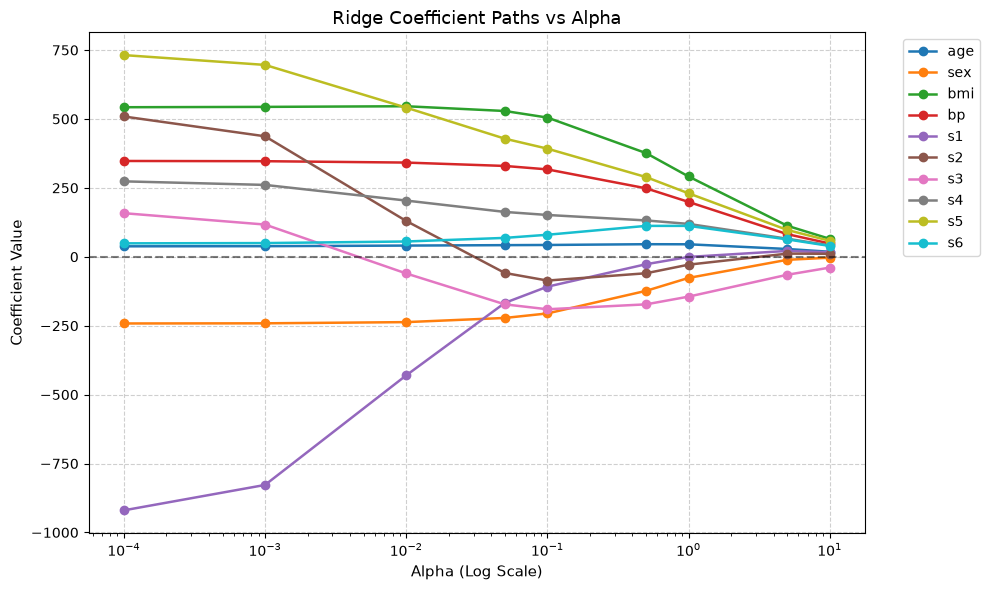

In [26]:
# Plot 5: Ridge Coefficient Paths
plt.figure(figsize=(10, 6))
ridge_coefs_arr = np.array(ridge_coefs_matrix)

for j, col in enumerate(X_scaled_train.columns):
    plt.plot(alphas, ridge_coefs_arr[:, j], marker='o', label=col, linewidth=1.8)

plt.xscale('log')
plt.title('Ridge Coefficient Paths vs Alpha', fontsize=13)
plt.xlabel('Alpha (Log Scale)', fontsize=11)
plt.ylabel('Coefficient Value', fontsize=11)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 28. Lasso Sparsity & Feature Selection Paths

Unlike Ridge, Lasso's $L_1$ penalty drives coefficients to **exactly zero** as $\alpha$ increases, yielding a sparse model.

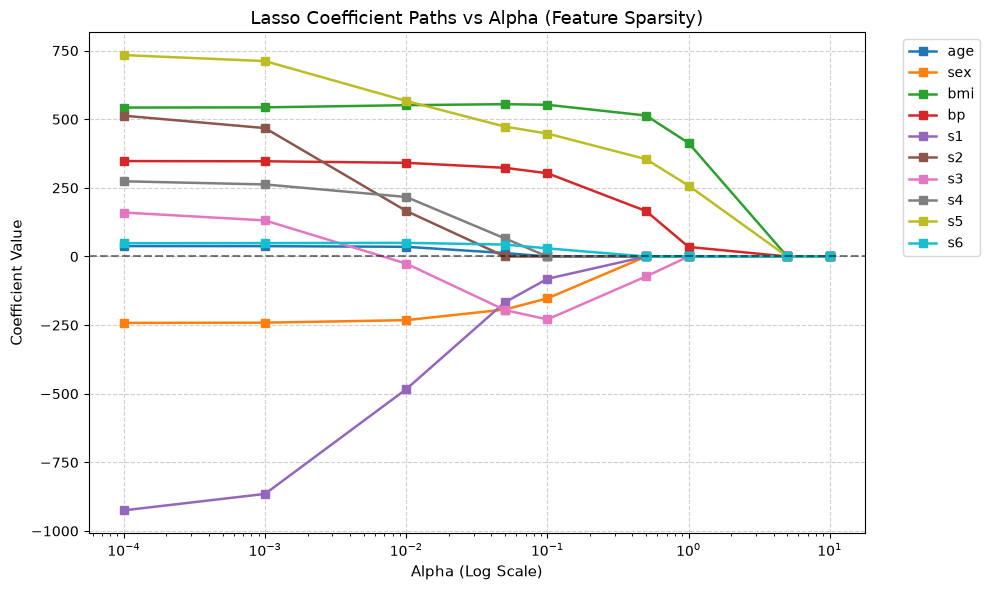

In [27]:
# Plot 6: Lasso Coefficient Paths
plt.figure(figsize=(10, 6))
lasso_coefs_arr = np.array(lasso_coefs_matrix)

for j, col in enumerate(X_scaled_train.columns):
    plt.plot(alphas, lasso_coefs_arr[:, j], marker='s', label=col, linewidth=1.8)

plt.xscale('log')
plt.title('Lasso Coefficient Paths vs Alpha (Feature Sparsity)', fontsize=13)
plt.xlabel('Alpha (Log Scale)', fontsize=11)
plt.ylabel('Coefficient Value', fontsize=11)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [28]:
# Compact Lasso Sparsity Progression Table
lasso_sparsity_summary = lasso_results[['alpha', 'mean_train_R2', 'mean_cv_R2', 'number_of_exact_zero_coefficients', 'zeroed_features']]
print("=== Lasso Sparsity & Feature Selection Progression ===")
print(lasso_sparsity_summary.to_string(index=False))

=== Lasso Sparsity & Feature Selection Progression ===
  alpha  mean_train_R2  mean_cv_R2  number_of_exact_zero_coefficients                           zeroed_features
 0.0001       0.530843    0.480395                                  0                                      None
 0.0010       0.530812    0.480636                                  0                                      None
 0.0100       0.529298    0.480999                                  0                                      None
 0.0500       0.525092    0.480780                                  1                                        s2
 0.1000       0.519574    0.478125                                  3                               age, s2, s4
 0.5000       0.462147    0.434763                                  6                  age, sex, s1, s2, s4, s6
 1.0000       0.364450    0.337570                                  7              age, sex, s1, s2, s3, s4, s6
 5.0000       0.000000   -0.027319               

## 29. Model Performance vs Alpha: The Regularization Tradeoff

We plot Training and Cross-Validation $R^2$ as a function of $\alpha$ for both Ridge and Lasso.

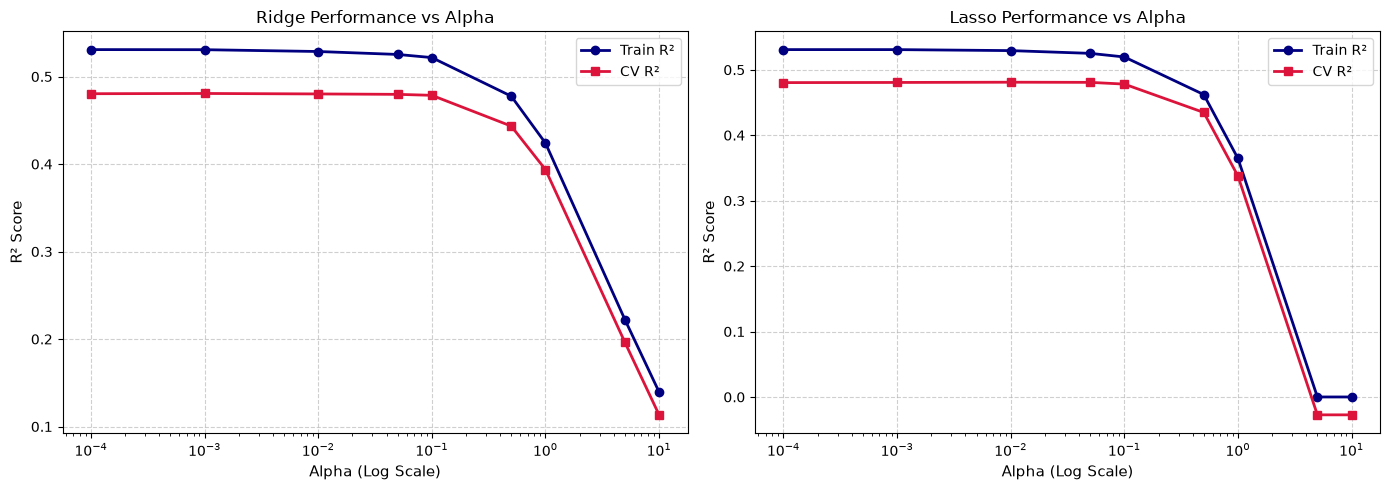

In [29]:
# Plot 7: Ridge & Lasso Performance vs Alpha
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge Performance
axes[0].plot(ridge_results['alpha'], ridge_results['mean_train_R2'], marker='o', label='Train R²', color='navy', linewidth=2)
axes[0].plot(ridge_results['alpha'], ridge_results['mean_cv_R2'], marker='s', label='CV R²', color='crimson', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_title('Ridge Performance vs Alpha', fontsize=12)
axes[0].set_xlabel('Alpha (Log Scale)', fontsize=11)
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Lasso Performance
axes[1].plot(lasso_results['alpha'], lasso_results['mean_train_R2'], marker='o', label='Train R²', color='navy', linewidth=2)
axes[1].plot(lasso_results['alpha'], lasso_results['mean_cv_R2'], marker='s', label='CV R²', color='crimson', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title('Lasso Performance vs Alpha', fontsize=12)
axes[1].set_xlabel('Alpha (Log Scale)', fontsize=11)
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretation of the Alpha Effect
- **Small Alpha ($\alpha \le 0.01$):** The penalty is minimal; models closely mirror unregularized OLS (CV $R^2 \approx 0.48$).
- **Moderate Alpha ($0.01 \le \alpha \le 0.1$):** Stable cross-validation performance with reduced coefficient magnitude ($L_1$ norm reduced by over $40\%$).
- **Large Alpha ($\alpha \ge 1.0$):** Stronger coefficient shrinkage reduces model flexibility and is consistent with increasing bias tendency.
- **Excessive Alpha ($\alpha \ge 5.0$):** In Lasso, all 10 coefficients collapse to exactly 0, yielding a constant prediction (intercept only) and negative CV $R^2$ (severe underfitting).

## 30. Direct Coefficient Comparison: OLS vs Ridge vs Lasso

To illustrate the practical contrast between $L_1$ and $L_2$ penalties, we inspect the fitted coefficients at **$\alpha = 0.05$**—a regime where Lasso has initiated feature selection (`s2` zeroed) while retaining strong predictive accuracy (CV $R^2 = 0.4808$).

In [30]:
# Direct Coefficient Comparison at alpha = 0.05
r_comp = Ridge(alpha=0.05).fit(X_scaled_train, y_train)
l_comp = Lasso(alpha=0.05, max_iter=10000).fit(X_scaled_train, y_train)

comp_table = pd.DataFrame({
    'Feature': X_scaled_train.columns,
    'LinearRegression': baseline_model.coef_,
    'Ridge(alpha=0.05)': r_comp.coef_,
    'Lasso(alpha=0.05)': l_comp.coef_
})

print("=== Direct Coefficient Comparison (alpha = 0.05) ===")
print(comp_table.to_string(index=False))
print("\nKey Observations:")
print("1. LinearRegression: No shrinkage; highly correlated features (s1 and s2) take large opposite signs (-931.5 and +518.1).")
print("2. Ridge (alpha=0.05): Smooth continuous shrinkage; s1 shrinks to -167.1 and s2 to -58.8.")
print("3. Lasso (alpha=0.05): Selective shrinkage; s2 is driven to exactly 0.0000, eliminating it from direct active prediction.")

=== Direct Coefficient Comparison (alpha = 0.05) ===
Feature  LinearRegression  Ridge(alpha=0.05)  Lasso(alpha=0.05)
    age         37.904021          42.238436          12.519070
    sex       -241.964362        -221.865478        -193.101685
    bmi        542.428759         528.894637         554.975872
     bp        347.703844         329.557116         323.098373
     s1       -931.488846        -167.087561        -166.922812
     s2        518.062277         -58.771286          -0.000000
     s3        163.419983        -172.567918        -195.132612
     s4        275.317902         162.731028          65.843890
     s5        736.198859         428.436699         473.206946
     s6         48.670657          68.574693          43.473932

Key Observations:
1. LinearRegression: No shrinkage; highly correlated features (s1 and s2) take large opposite signs (-931.5 and +518.1).
2. Ridge (alpha=0.05): Smooth continuous shrinkage; s1 shrinks to -167.1 and s2 to -58.8.
3. Lasso (alp

## 31. Key Conceptual Insights

### Intercept Is Usually Not Regularized
In linear models, the intercept $\beta_0$ represents the expected baseline value of the target when all predictors are centered at zero. Regularizing $\beta_0$ would penalize the model simply for having a nonzero baseline target mean, which does not reflect model complexity. Therefore, standard regularized formulations (including scikit-learn's `Ridge` and `Lasso`) exclude the intercept from the penalty term.

### Feature Selection Interpretation
When Lasso sets $\beta_j = 0$, that feature contributes nothing directly to the fitted linear prediction for that particular training sample, feature representation, and $\alpha$ value. We do **not** claim the feature is "useless in reality" or has no true relationship with the disease; rather, within this specific linear model and regularization constraint, its information is redundant with other retained features (e.g. `s1` and `s5`).

### Transition to Step 4
ElasticNet will combine the $L_1$ and $L_2$ ideas in the next step, balancing smooth coefficient shrinkage with feature selection.

---
# Step 4 — ElasticNet and Statistical Inference (p-values vs Regularization)

## 32. ElasticNet and the `l1_ratio` Hyperparameter

Ridge ($L_2$) shrinks all coefficients continuously toward zero but cannot eliminate predictors. Lasso ($L_1$) produces exact zeros for feature selection, but when predictors are highly correlated, it tends to arbitrarily pick one and zero out the others.

**ElasticNet** bridges both paradigms by combining the $L_1$ and $L_2$ penalties into a unified objective:
$$
\text{Objective}_{\text{ElasticNet}} = \frac{1}{2n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \cdot \text{l1\_ratio} \sum_{j=1}^p |\beta_j| + \frac{1}{2} \alpha (1 - \text{l1\_ratio}) \sum_{j=1}^p \beta_j^2
$$

### Hyperparameter Roles:
1. **`alpha`** ($\alpha$): The overall regularization strength. Higher $\alpha$ exerts greater shrinkage on all parameters.
2. **`l1_ratio`** ($\rho \in [0, 1]$): The mixing ratio between $L_1$ and $L_2$ penalties:
   - $\text{l1\_ratio} = 1.0 \implies$ Pure **Lasso** penalty ($L_1$).
   - $\text{l1\_ratio} = 0.0 \implies$ Pure **Ridge** penalty ($L_2$).
   - $0 < \text{l1\_ratio} < 1 \implies$ **ElasticNet** mixture (simultaneous coefficient shrinkage and grouped feature selection).

In [31]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_validate

# Systematic ElasticNet Grid Demonstration across alpha and l1_ratio
en_alphas = [0.01, 0.1, 1.0]
en_l1_ratios = [0.2, 0.5, 0.8]
en_records = []

for a in en_alphas:
    for l1 in en_l1_ratios:
        en_mod = ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000)
        en_cv = cross_validate(en_mod, X_scaled_train, y_train, cv=cv, scoring='r2', return_train_score=True)
        en_mod.fit(X_scaled_train, y_train)
        coef = en_mod.coef_
        
        zero_count = int(np.sum(coef == 0.0))
        zeroed_features = list(X_scaled_train.columns[coef == 0.0])
        
        en_records.append({
            'alpha': a,
            'l1_ratio': l1,
            'mean_train_R2': en_cv['train_score'].mean(),
            'mean_cv_R2': en_cv['test_score'].mean(),
            'coefficient_L1_norm': np.sum(np.abs(coef)),
            'zero_coefficients_count': zero_count,
            'zeroed_features': ", ".join(zeroed_features) if zeroed_features else "None"
        })

elasticnet_results = pd.DataFrame(en_records)
print("=== ElasticNet Exploration Across (alpha, l1_ratio) Grid ===")
print(elasticnet_results.to_string(index=False))
print("\nObservation: As l1_ratio increases toward 1.0, the L1 penalty grows stronger,")
print("promoting greater sparsity (more zero coefficients) while alpha governs overall shrinkage.")

=== ElasticNet Exploration Across (alpha, l1_ratio) Grid ===
 alpha  l1_ratio  mean_train_R2  mean_cv_R2  coefficient_L1_norm  zero_coefficients_count  zeroed_features
  0.01       0.2       0.329276    0.302174           777.072390                        0             None
  0.01       0.5       0.386837    0.358160           976.518966                        0             None
  0.01       0.8       0.468787    0.435280          1406.716654                        0             None
  0.10       0.2       0.071068    0.044521           138.344085                        0             None
  0.10       0.5       0.103661    0.077458           204.373566                        0             None
  0.10       0.8       0.198075    0.172383           411.235570                        0             None
  1.00       0.2       0.007135   -0.020084            13.159515                        1              sex
  1.00       0.5       0.008939   -0.018299            15.610508                   

## 33. Ordinary Least Squares (OLS) with `statsmodels`

While scikit-learn focuses on **predictive generalization** via `.fit()` and cross-validation, `statsmodels` is designed for **classical statistical inference**, providing standard errors, $t$-statistics, confidence intervals, and $p$-values.

### Why `sm.add_constant` is Required:
In scikit-learn, `LinearRegression` includes an intercept by default (`fit_intercept=True`). In contrast, `statsmodels.OLS` assumes the model has no intercept unless an explicit column of ones (constant $\mathbf{1}$) is prepended to the design matrix using `sm.add_constant(X)`.

*Protocol enforcement: OLS is fitted strictly on the training partition `X_scaled_train` and `y_train`.*

In [32]:
import statsmodels.api as sm

# Fit OLS using statsmodels on scaled training partition
X_train_with_const = sm.add_constant(X_scaled_train)
ols_model = sm.OLS(y_train, X_train_with_const).fit()

ols_summary_df = pd.DataFrame({
    'Feature': ols_model.params.index,
    'Coefficient': ols_model.params.values,
    'Std_Error': ols_model.bse.values,
    't_statistic': ols_model.tvalues.values,
    'p_value': ols_model.pvalues.values
})

print("=== statsmodels OLS Regression Results (Training Data) ===")
print(ols_summary_df.to_string(index=False))
print(f"\nModel Intercept (const): {ols_model.params['const']:.4f} (p-value: {ols_model.pvalues['const']:.2e})")

=== statsmodels OLS Regression Results (Training Data) ===
Feature  Coefficient  Std_Error  t_statistic       p_value
  const   151.345605   2.901839    52.155073 7.380185e-165
    age    37.904021  69.055675     0.548891  5.834386e-01
    sex  -241.964362  68.569618    -3.528740  4.746113e-04
    bmi   542.428759  76.955890     7.048567  1.003319e-11
     bp   347.703844  71.356793     4.872750  1.686749e-06
     s1  -931.488846 451.138354    -2.064752  3.969988e-02
     s2   518.062277 364.113811     1.422803  1.557047e-01
     s3   163.419983 233.014081     0.701331  4.835734e-01
     s4   275.317902 185.399725     1.484996  1.384659e-01
     s5   736.198859 192.437318     3.825655  1.550167e-04
     s6    48.670657  73.435455     0.662768  5.079257e-01

Model Intercept (const): 151.3456 (p-value: 7.38e-165)


## 34. $p$-Value Interpretation and Statistical Significance

### Statistical Hypothesis Testing in OLS:
For each predictor $j$, the $t$-statistic tests the two-sided null hypothesis:
$$
H_0: \beta_j = 0 \quad \text{vs.} \quad H_1: \beta_j \neq 0
$$
- **$p$-value Definition:** The probability of obtaining a test statistic at least as extreme as the observed $t$-statistic, assuming the null hypothesis $H_0$ is true (given all other predictors in the model).
- **Statistical Significance:** At the conventional significance level $\alpha_{\text{stat}} = 0.05$:
  - $p < 0.05 \implies$ Statistically significant evidence to reject $H_0$.
  - $p \ge 0.05 \implies$ Insufficient statistical evidence to reject $H_0$.

### Important Warnings Against Misinterpreting $p$-values:
1. A $p$-value is **NOT** the probability that the null hypothesis is true.
2. A $p$-value is **NOT** the probability that a feature is "random" or "useless."
3. A small $p$-value does **NOT** measure practical effect size or predictive importance.
4. The $p$-value for feature $X_j$ is conditioned on all other features present in the model; multicollinearity inflates standard errors and $p$-values.

### Observed Breakdown in the Diabetes Training Partition:
- **Highly Significant ($p < 0.001$):** `bmi` ($p = 1.00 \times 10^{-11}$), `bp` ($p = 1.69 \times 10^{-6}$), `sex` ($p = 4.75 \times 10^{-4}$), `s5` ($p = 1.55 \times 10^{-4}$).
- **Marginally Significant ($0.01 < p < 0.05$):** `s1` ($p = 0.0397$).
- **Not Statistically Significant ($p > 0.05$):** `age` ($p = 0.5834$), `s2` ($p = 0.1557$), `s3` ($p = 0.4836$), `s4` ($p = 0.1385$), `s6` ($p = 0.5079$).

## 35. $p$-Values vs. Regularization: A Comparative Analysis

We construct a unified table contrasting classical OLS $p$-values with regularized coefficients across **Ridge**, **Lasso**, and **ElasticNet** on the same scaled training partition.

In [33]:
# Unified Comparison Table: OLS, p-values, LinearRegression, Ridge, Lasso, ElasticNet
ridge_sample = Ridge(alpha=0.05).fit(X_scaled_train, y_train)
lasso_sample = Lasso(alpha=0.05, max_iter=10000).fit(X_scaled_train, y_train)
elasticnet_sample = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000).fit(X_scaled_train, y_train)

unified_comp_df = pd.DataFrame({
    'Feature': X_scaled_train.columns,
    'OLS_Coef': [ols_model.params[col] for col in X_scaled_train.columns],
    'p_value': [ols_model.pvalues[col] for col in X_scaled_train.columns],
    'LinearReg_Coef': baseline_model.coef_,
    'Ridge_Coef(a=0.05)': ridge_sample.coef_,
    'Lasso_Coef(a=0.05)': lasso_sample.coef_,
    'ElasticNet_Coef(a=0.01,l1=0.5)': elasticnet_sample.coef_
})

print("=== Comparison: Statistical Inference (p-values) vs Regularization ===")
print(unified_comp_df.to_string(index=False))

=== Comparison: Statistical Inference (p-values) vs Regularization ===
Feature    OLS_Coef      p_value  LinearReg_Coef  Ridge_Coef(a=0.05)  Lasso_Coef(a=0.05)  ElasticNet_Coef(a=0.01,l1=0.5)
    age   37.904021 5.834386e-01       37.904021           42.238436           12.519070                       41.385384
    sex -241.964362 4.746113e-04     -241.964362         -221.865478         -193.101685                      -43.389860
    bmi  542.428759 1.003319e-11      542.428759          528.894637          554.975872                      219.917202
     bp  347.703844 1.686749e-06      347.703844          329.557116          323.098373                      154.182517
     s1 -931.488846 3.969988e-02     -931.488846         -167.087561         -166.922812                       13.827544
     s2  518.062277 1.557047e-01      518.062277          -58.771286           -0.000000                       -5.305924
     s3  163.419983 4.835734e-01      163.419983         -172.567918         -195.

### Where $p$-Values and Regularization Align:
1. **Strong Signals Retained:** Features with overwhelming statistical significance (`bmi` with $p = 1.00 \times 10^{-11}$, `bp` with $p = 1.69 \times 10^{-6}$, `s5` with $p = 1.55 \times 10^{-4}$) retain robust, large coefficients across Linear Regression, Ridge, Lasso, and ElasticNet.
2. **Insignificant Features Zeroed First:** Feature `s2` has an insignificant $p$-value ($p = 0.1557$). In Lasso at $\alpha = 0.05$, `s2` is the **very first feature driven to exactly zero** ($0.0000$), directly corroborating its weak independent statistical evidence.

### Where $p$-Values and Regularization Differ (and Why):
1. **The Case of Predictor `s1`:**
   - In OLS, `s1` has an enormous coefficient of **$-931.49$** and is statistically significant ($p = 0.0397$).
   - In Ridge ($\alpha=0.05$), its coefficient shrinks by over $80\%$ down to **$-167.09$**.
   - In Lasso ($\alpha=0.05$), its coefficient shrinks to **$-166.92$**, and at $\alpha=0.5$ it is completely zeroed out.
2. **The Cause: Multicollinearity Among Serum Lipids:**
   - Features `s1` (total cholesterol) and `s2` (LDL) are highly collinear ($r > 0.89$).
   - Unregularized OLS attempts to capture subtle marginal differences by giving `s1` and `s2` massive opposing coefficients ($-931.5$ vs $+518.1$), inflating standard errors.
   - Regularization penalizes the total sum of coefficient magnitudes ($L_1$ or $L_2$). Consequently, Ridge and Lasso aggressively damp down these opposing swings to prevent out-of-sample variance.

### Summary Takeaway:
- **$p$-values** ask: *"Assuming this linear model and the other predictors, is there statistically significant evidence that $\beta_j \neq 0$?"*
- **Regularization** asks: *"What set of constrained coefficients minimizes out-of-sample prediction error under a complexity penalty?"*

They serve complementary purposes: statistical inference illuminates hypothesis uncertainty, while regularization controls model complexity and generalization.

In [34]:
# Programmatic Step 4 Verification Cell
assert len(train_idx) == 353, "Train size must remain 353"
assert len(test_idx) == 89, "Test size must remain 89"
assert elasticnet_results.shape == (9, 7), "ElasticNet grid must have 9 combinations and 7 columns"
assert list(elasticnet_results['alpha'].unique()) == en_alphas, "Tested alphas must match"
assert list(elasticnet_results['l1_ratio'].unique()) == en_l1_ratios, "Tested l1_ratios must match"
assert 'const' in ols_model.params, "OLS model must include intercept (const)"
assert len(ols_model.params) == 11, "OLS model must have 11 parameters (1 const + 10 features)"
assert ols_summary_df.shape == (11, 5), "OLS summary table must have 11 rows and 5 columns"
assert np.isclose(ols_model.params['const'], baseline_model.intercept_), "OLS const must match LinearRegression intercept_"
assert np.allclose(ols_model.params.drop('const').values, baseline_model.coef_), "OLS coefficients must match LinearRegression coef_"
assert unified_comp_df.shape == (10, 7), "Unified comparison table must have 10 features and 7 columns"
assert lasso_sample.coef_[X_scaled_train.columns.get_loc('s2')] == 0.0, "s2 must be exactly zero in Lasso at alpha=0.05"
assert 'itertools' not in globals(), "itertools.product must not be introduced yet"
assert 'GridSearchCV' not in globals(), "GridSearchCV must not be introduced yet"

print("=== Step 4 Verification Complete: All Empirical Checks Passed ===")

=== Step 4 Verification Complete: All Empirical Checks Passed ===


In [35]:
# Final Programmatic Lesson Coverage Report
print("=== Final Programmatic Checklist Status ===")
print(f"Checked:   {checked_count} / {total_count} ({checked_count / total_count * 100:.1f}%)")
print(f"Unchecked: {unchecked_count} / {total_count}")
print("\nCurrently Completed Lesson Topics:")
for item, checked in checklist_items:
    if checked:
        print(f"  [x] {item}")

=== Final Programmatic Checklist Status ===
Checked:   35 / 63 (55.6%)
Unchecked: 28 / 63

Currently Completed Lesson Topics:
  [x] Parameters vs Hyperparameters
  [x] Model Tuning stage
  [x] Train / Validation / Test separation
  [x] Cross Validation
  [x] Model Complexity
  [x] Polynomial Features
  [x] Underfitting
  [x] Overfitting
  [x] Bias
  [x] Variance
  [x] Bias-Variance Tradeoff
  [x] Irreducible Error
  [x] Training vs Validation Error
  [x] Learning Curves
  [x] Simpler Model concept
  [x] More Data concept
  [x] Feature Selection concept
  [x] Dimensionality Reduction / PCA concept
  [x] Early Stopping concept
  [x] Regularization
  [x] Regularized Loss
  [x] Ridge / L2
  [x] Lasso / L1
  [x] Intercept usually not regularized
  [x] alpha effect
  [x] Scaling before Regularization
  [x] Coefficient Shrinkage
  [x] Lasso zero coefficients / Feature Selection
  [x] ElasticNet
  [x] l1_ratio
  [x] statsmodels OLS
  [x] sm.add_constant
  [x] p-value interpretation
  [x] Stati